In [315]:
import warnings
warnings.filterwarnings("ignore")


# Load the dataset-64  as numpy array

In [316]:
import numpy as np

data = np.array([
    [1, 3.08355737],
    [2, 2.71790051],
    [3, 2.16807318],
    [4, 2.00973320],
    [5, 1.44080472],
    [6, 1.62898576],
    [7, 1.22969925],
    [8, 1.35318577],
    [9, 1.41176152],
    [10, 1.14526021],
    [11, 1.34932446],
    [12, 1.36416543],
    [13, 1.24059808],
    [14, 1.35784411],
    [15, 1.35702884],
    [16, 1.48576009],
    [17, 1.50342143],
    [18, 1.18692255],
    [19, 1.22197402],
    [20, 1.35107946],
    [21, 1.27011323],
    [22, 1.11035931],
    [23, 1.15241206],
    [24, 1.14785719],
    [25, 1.62040973],
    [26, 1.22733605],
    [27, 1.30371857],
    [28, 1.13522875],
    [29, 1.26920664],
    [30, 1.24683869],
    [31, 1.46587861],
    [32, 1.19352829],
    [33, 1.47638559],
    [34, 1.26788020],
    [35, 1.49753976],
    [36, 1.10720062],
    [37, 1.30404067],
    [38, 1.14643431],
    [39, 1.13234997],
    [40, 1.25099957],
    [41, 1.49324453],
    [42, 1.18840361],
    [43, 1.11350167],
    [44, 1.16263533],
    [45, 1.15512657],
    [46, 1.30094981],
    [47, 1.20506239],
    [48, 1.20636976],
    [49, 1.30624843],
    [50, 1.13225245],
    [51, 1.22737157],
    [52, 1.47139275],
    [53, 1.00664759],
    [54, 1.26827443],
    [55, 1.27458704],
    [56, 0.99191314],
    [57, 1.03172159],
    [58, 1.53052270],
    [59, 1.43704510],
    [60, 1.41123366]
])
# Save the array permanently to disk
np.save('set-64.npy', data)


print(data.shape)  # (60, 2)


(60, 2)


## **Plotting the raw data from dataset-64**

### $y_t$ vs t for $1 \leq t \leq 60$ 


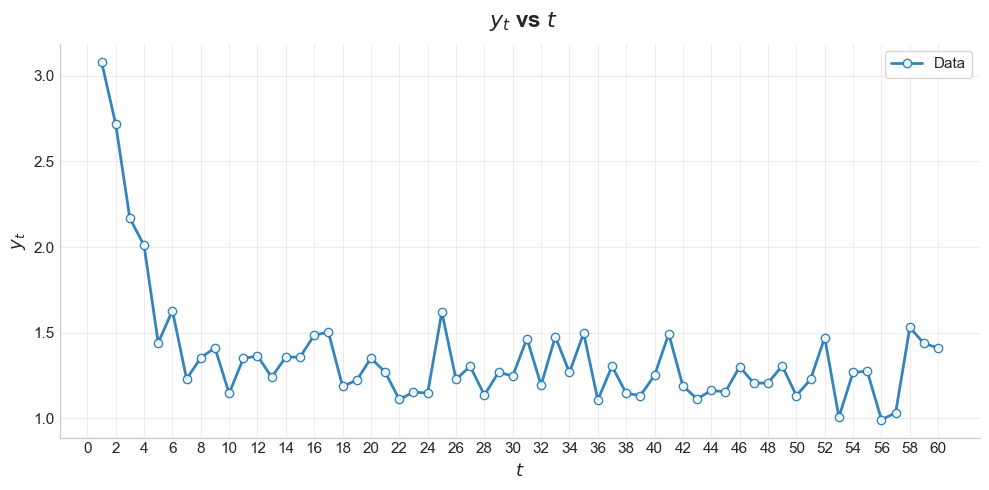

In [317]:
#Plots y_t vs t from set-64.dat
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load data 
x = list(range(1, 61))
# data = pd.read_csv('set-64.dat', delim_whitespace=True, header=None).to_numpy()
data = np.load('set-64.npy')
y = data[:, 1]

# Style settings 
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

#  Plot 

ax.plot(
    x, y,
    marker='o',
    markersize=6,
    linestyle='-',
    linewidth=2,
    color='#1f77b4',
    markerfacecolor='white',
    markeredgecolor='#1f77b4',
    alpha=0.9,
    label='Data',
)

# Titles and labels
ax.set_title(" $y_t$ vs $t$ ", fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel("$t$", fontsize=13)
ax.set_ylabel("$y_t$", fontsize=13)
ax.legend(frameon=True, fontsize=11, loc='best')
ax.set_xticks(np.arange(0, 61, 2))   # ticks at 0, 5, 10, ..., 60


#  Grid and aesthetics 
ax.grid(alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=11)

#  Layout 
plt.tight_layout()
plt.show()


# **MODEL 1 : Exponential model**

Loaded 60 data points.
\n--- Starting Osborne's Iteration 
Iter 1: change = 1.77e-01
Iter 2: change = 1.91e-01
Iter 3: change = 6.42e-02
Iter 4: change = 4.70e-02
Iter 5: change = 3.23e-02
Iter 6: change = 2.14e-02
Iter 7: change = 1.35e-02
Iter 8: change = 7.32e-03
Iter 9: change = 3.57e-03
Iter 10: change = 1.93e-03
Iter 11: change = 1.74e-02
Iter 12: change = 2.32e-02
Iter 13: change = 1.88e-02
Iter 14: change = 1.13e-02
Iter 15: change = 4.28e-03
Iter 16: change = 1.13e-03
Iter 17: change = 2.44e-04
Iter 18: change = 4.85e-05
Iter 19: change = 9.30e-06
Iter 20: change = 1.76e-06
Iter 21: change = 3.31e-07
Iter 22: change = 6.23e-08
Iter 23: change = 1.17e-08
Iter 24: change = 2.19e-09
Convergence reached.
\n--- Fit Successful ---
Final g vector: [ 0.3433 -0.8133  0.4698]
Roots (e^b1, e^b2): [1.0017 0.7294]
\nOptimized Parameters (from PDF algorithm):
  alpha_0 (a0): 1.000000 (This was our input)
  alpha_1 (a1): 0.239046
  beta_1  (b1): 0.001739
  alpha_2 (a2): 2.491671
  beta_2  (b

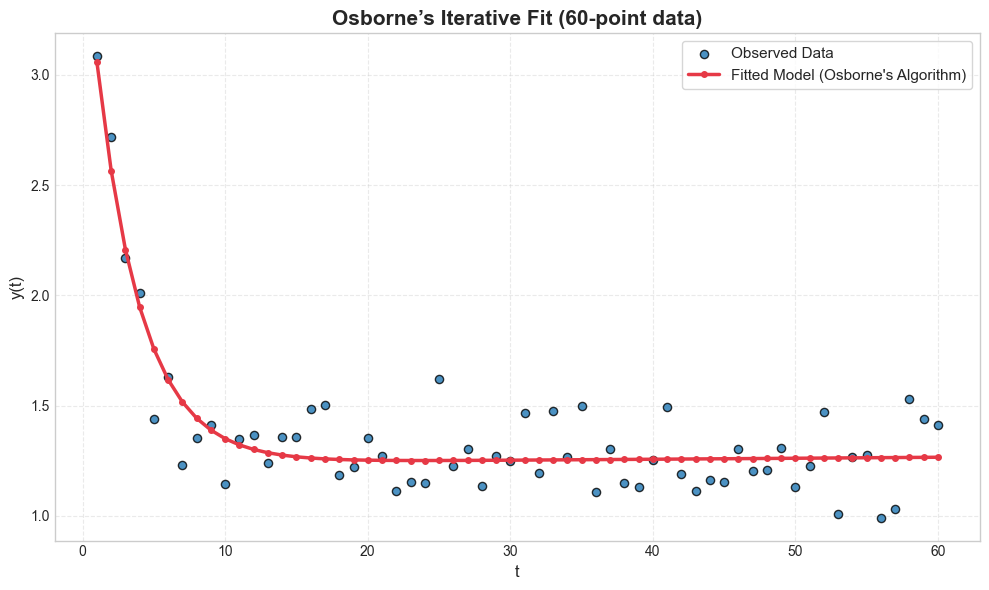

In [318]:
%reset -f
#plots exponential fitting (2-exponential model)
import numpy as np
import pandas as pd
import io
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# data = pd.read_csv('set-64.dat', delim_whitespace=True, header=None).to_numpy()
data = np.load('set-64.npy')
t_data = data[:, 0]
y_data = data[:, 1]
n = len(t_data)
print(f"Loaded {n} data points.")

#  Detrend the Data 
# We subtract the constant offset a0 found in the previous fit.
# This makes the data fit the PDF's model: y' = a1*exp(b1*t) + a2*exp(b2*t)
a0_offset = 1
Y = y_data - a0_offset
Y = Y.reshape(-1, 1) # Make it a column vector [n x 1]

#  Define Gk Matrices  
# We build Gk_T (Gk transposed) as (n-2) x n matrices
n_minus_2 = n - 2
G0_T = np.zeros((n_minus_2, n))
G1_T = np.zeros((n_minus_2, n))
G2_T = np.zeros((n_minus_2, n))

for i in range(n_minus_2):
    G0_T[i, i] = 1
    G1_T[i, i+1] = 1
    G2_T[i, i+2] = 1

# Transpose them to get the n x (n-2) matrices Gk
G0 = G0_T.T
G1 = G1_T.T
G2 = G2_T.T

# Pre-calculate components for the B(g) matrix
U0 = G0_T @ Y
U1 = G1_T @ Y
U2 = G2_T @ Y

C00 = G0_T @ G0
C01 = G0_T @ G1
C02 = G0_T @ G2
C11 = G1_T @ G1
C12 = G1_T @ G2
C22 = G2_T @ G2

# Make Cjk symmetric (Cjk = Ckj.T)
C10 = C01.T
C20 = C02.T
C21 = C12.T

#  Implement Osborne's Iterative Algorithm 

def build_B_matrix(g_vec):
    """ Builds the 3x3 B(g) matrix (Source 98, 100) """
    g0, g1, g2 = g_vec
    
    # G = g0*G0 + g1*G1 + g2*G2
    G = g0 * G0 + g1 * G1 + g2 * G2
    
    # A = (G^T G)^-1
    G_T_G = G.T @ G
    try:
        A = np.linalg.inv(G_T_G)
    except np.linalg.LinAlgError:
        print("Error: G^T G is singular. Using pseudo-inverse.")
        A = np.linalg.pinv(G_T_G)
        
    v = A @ G.T @ Y

    U = [U0, U1, U2]
    C = [
        [C00, C01, C02],
        [C10, C11, C12],
        [C20, C21, C22]
    ]
    
    B = np.zeros((3, 3))
    
    # b_jk = U_k.T @ A @ U_j + v.T @ (C_kj + C_jk) @ v + U_j.T @ A @ U_k
    for j in range(3):
        for k in range(3):
            term1 = U[k].T @ A @ U[j]
            term2 = v.T @ (C[k][j] + C[j][k]) @ v
            term3 = U[j].T @ A @ U[k]
            B[j, k] = (term1 + term2 + term3)[0, 0] # Extract scalar
            
    return B

# Algorithm Step 1: Initial guess
g = np.array([5.0, -3.0, 5])
g = g / np.linalg.norm(g) # Normalize

max_iter = 1000
tolerance = 1e-8
print("\\n--- Starting Osborne's Iteration ")

for i in range(max_iter):
    g_old = g
    
    # Step 2: Compute B(g)
    B = build_B_matrix(g)
    
    # Step 2: Compute eigenvector for minimum (absolute) eigenvalue
    eigenvalues, eigenvectors = np.linalg.eig(B)
    min_eig_index = np.argmin(np.abs(eigenvalues))
    g_new = eigenvectors[:, min_eig_index]
    
    # Step 3: Normalize
    g_new = g_new / np.linalg.norm(g_new)
    
    # Ensure consistent sign
    if np.dot(g_new, g_old) < 0:
        g_new = -g_new
        
    g = g_new
    
    # Check for convergence
    change = np.linalg.norm(g - g_old)
    print(f"Iter {i+1}: change = {change:.2e}")
    if change < tolerance:
        print("Convergence reached.")
        break

print("\\n--- Fit Successful ---")
print(f"Final g vector: {g}")

#  Extract Parameters from g 

g_hat_0, g_hat_1, g_hat_2 = g

# Step 5a: Find roots of g2*x^2 + g1*x + g0 = 0
poly = [g_hat_2, g_hat_1, g_hat_0]
roots = np.roots(poly)
print(f"Roots (e^b1, e^b2): {roots}")

# Step 5b: Find betas (b1 = log(root1), b2 = log(root2))
# Use .real in case of small imaginary parts from noise
betas = np.log(roots.real)
b1_fit, b2_fit = betas

# Step 5c: Find alphas using linear least squares
# (Source 13-14) on the detrended data Y
X = np.zeros((n, 2))
X[:, 0] = np.exp(b1_fit * t_data)
X[:, 1] = np.exp(b2_fit * t_data)

# Solve (X.T X)a = X.T Y
alphas, _, _, _ = np.linalg.lstsq(X, Y.flatten(), rcond=None)
a1_fit, a2_fit = alphas

print("\\nOptimized Parameters (from PDF algorithm):")
print(f"  alpha_0 (a0): {a0_offset:.6f} (This was our input)")
print(f"  alpha_1 (a1): {a1_fit:.6f}")
print(f"  beta_1  (b1): {b1_fit:.6f}")
print(f"  alpha_2 (a2): {a2_fit:.6f}")
print(f"  beta_2  (b2): {b2_fit:.6f}")

#  Generate Plot

def model(t, a0, a1, b1, a2, b2):
    return a0 + a1 * np.exp(b1 * t) + a2 * np.exp(b2 * t)

t_fit = np.linspace(min(t_data), max(t_data), n)
y_fit = model(t_fit, a0_offset, a1_fit, b1_fit, a2_fit, b2_fit)



plt.figure(figsize=(10, 6))

# Plot actual data
plt.scatter(
    t_data, y_data,
    label='Observed Data',
    s=35,
    color='#1f77b4',
    edgecolors='k',
    alpha=0.8
)

# Plot fitted curve (exactly 60 points)
plt.plot(
    t_data, y_fit,
    color='#e63946',
    linewidth=2.5,
    marker='o',
    markersize=4,
    label="Fitted Model (Osborne's Algorithm)"
)


plt.title("Osborne’s Iterative Fit (60-point data)", fontsize=15, weight='bold')
plt.xlabel("t", fontsize=12)
plt.ylabel("y(t)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.show()


### **Normality check -QQ plot and histogram of residuals for exponential fit**

Residual mean: -6.7909e-06
Residual std dev: 1.4841e-01
estimate of σ² = 0.023206176375670896
\n--- Normality Tests ---
Shapiro–Wilk test:       statistic = 0.9807, p-value = 0.4584
Kolmogorov–Smirnov test: statistic = 0.0839, p-value = 0.7610
Jarque–Bera test:        statistic = 0.4210, p-value = 0.8102


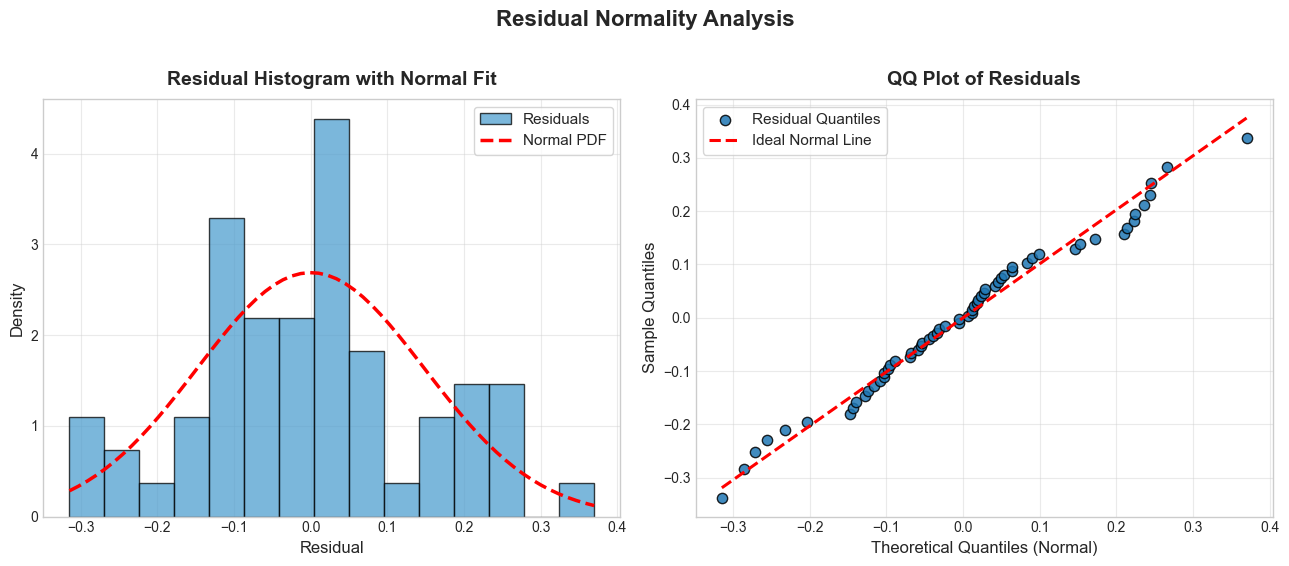

In [319]:
#plots QQ plot and histogram of residuals for exponential fit

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


residuals = y_data - y_fit

#  Descriptive statistics
mean_res = np.mean(residuals)
std_res = np.std(residuals, ddof=1)

print(f"Residual mean: {mean_res:.4e}")
print(f"Residual std dev: {std_res:.4e}")
print("estimate of σ² =", np.sum(residuals*residuals) / (len(residuals)-4))
#  Normality tests
shapiro_stat, shapiro_p = stats.shapiro(residuals)
ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(mean_res, std_res))
jb_stat, jb_p = stats.jarque_bera(residuals)

print("\\n--- Normality Tests ---")
print(f"Shapiro–Wilk test:       statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
print(f"Kolmogorov–Smirnov test: statistic = {ks_stat:.4f}, p-value = {ks_p:.4f}")
print(f"Jarque–Bera test:        statistic = {jb_stat:.4f}, p-value = {jb_p:.4f}")

#  Plots
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# (a) Histogram with normal curve 
n, bins, patches = axes[0].hist(
    residuals,
    bins=15,
    density=True,
    color='#4f9fcf',
    edgecolor='black',
    alpha=0.75,
    label='Residuals',
)


x = np.linspace(min(residuals), max(residuals), 60)
axes[0].plot(
    x,
    stats.norm.pdf(x, mean_res, std_res),
    'r--',
    lw=2.5,
    label='Normal PDF',
)

axes[0].set_title("Residual Histogram with Normal Fit", fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel("Residual", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].legend(frameon=True, fontsize=11)
axes[0].grid(alpha=0.4)

# (b) QQ Plot 
(quantiles, theoretical), (slope, intercept, r) = stats.probplot(residuals, dist="norm",sparams=(mean_res,std_res))

# Custom scatter and ideal line
axes[1].scatter(
    theoretical,
    quantiles,
    color="#1f77b4",
    edgecolor='black',
    s=55,
    alpha=0.85,
    label="Residual Quantiles"
)
axes[1].plot(
    theoretical,
    slope * theoretical + intercept,
    'r--',
    lw=2.2,
    label="Ideal Normal Line"
)

axes[1].set_title("QQ Plot of Residuals", fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel("Theoretical Quantiles (Normal)", fontsize=12)
axes[1].set_ylabel("Sample Quantiles", fontsize=12)
axes[1].legend(frameon=True, fontsize=11)
axes[1].grid(alpha=0.4)

# Layout
plt.suptitle("Residual Normality Analysis", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### **Residuals vs t for exponential fit**

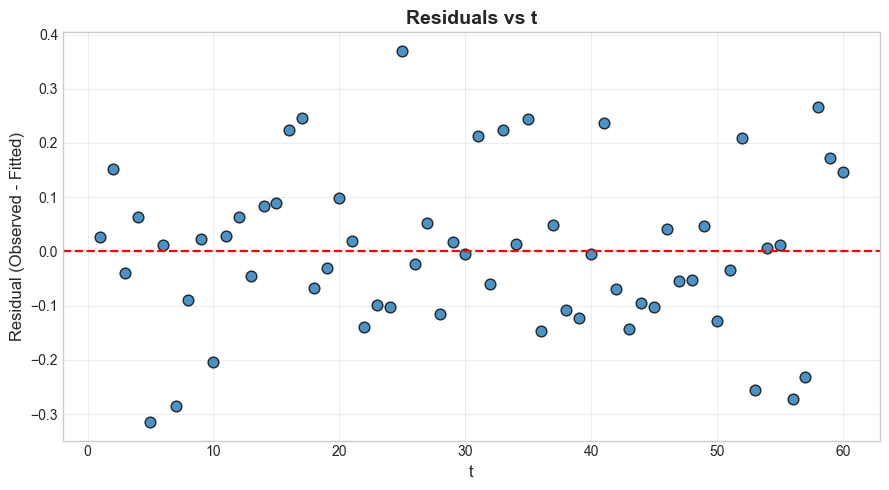

In [320]:
#plots Residuals vs t for exponential fit
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(9, 5))
plt.scatter(t_data, residuals, color="#1f77b4", edgecolors="k", s=60, alpha=0.8)
plt.axhline(0, color='red', linestyle='--', linewidth=1.6)

plt.title("Residuals vs t", fontsize=14, weight='bold')
plt.xlabel("t", fontsize=12)
plt.ylabel("Residual (Observed - Fitted)", fontsize=12)
plt.grid(alpha=0.35)
plt.tight_layout()
plt.show()


### **FIM and Confidence Interval Calculation for Exponential Fit**

In [321]:
# FIM and Confidence Interval Calculation for Exponential Fit

import scipy.stats as stats

print("\\n--- 95% Confidence Interval Calculation (Osborne) ---")

try:
    # Define the detrended model and its Jacobian
    # This is the 4-parameter model that was actually fitted.
    
    def model_detrended(t, p):
        """Model: y' = a1*e^(b1*t) + a2*e^(b2*t)"""
        a1, b1, a2, b2 = p
        return a1 * np.exp(b1 * t) + a2 * np.exp(b2 * t)
    
    def jacobian_detrended(p, t):
        """Jacobian for the 4-parameter detrended model."""
        a1, b1, a2, b2 = p
        e1, e2 = np.exp(b1 * t), np.exp(b2 * t)
        
        J = np.empty((len(t), 4))
        J[:, 0] = e1               # d/da1
        J[:, 1] = a1 * t * e1    # d/db1
        J[:, 2] = e2               # d/da2
        J[:, 3] = a2 * t * e2    # d/db2
        return J

    #  Get final parameters and residuals
    # The 4 parameters that were estimated
    p_opt = np.array([a1_fit, b1_fit, a2_fit, b2_fit])
    
    # Calculate residuals against the detrended data 'Y'
    y_pred_detrended = model_detrended(t_data, p_opt)
    residual_values = Y.flatten() - y_pred_detrended # Y was (y_data - a0_offset)
    
    rss = np.sum(residual_values**2)
    
    # 3. Calculate FIM and Covariance
    n = len(t_data) # Number of data points
    m = len(p_opt)  # Number of *estimated* parameters (4)
    df = n - m
    
    # Estimate of noise variance
    sigma2 = rss / max(1, df)
    
    # Get the final Jacobian for the 4-param model
    J_final = jacobian_detrended(p_opt, t_data)
    
    # Calculate Fisher Information Matrix (FIM)
    J_T_J = J_final.T @ J_final
    fim = J_T_J / sigma2
    
    # Calculate Covariance Matrix (Inverse of FIM)
    cov = np.linalg.inv(fim)
    
    # Standard Errors
    param_std = np.sqrt(np.diag(cov))

    #  Calculate Confidence Intervals 
    alpha = 0.05  # 95% confidence
    t_crit = stats.t.ppf(1 - alpha / 2, df)

    margin_of_error = t_crit * param_std
    ci_lower = p_opt - margin_of_error
    ci_upper = p_opt + margin_of_error

    #  Print the FIM 
    print("\\n--- Fisher Information Matrix (FIM) [4x4] ---")
    np.set_printoptions(precision=4, suppress=True)
    print(fim)
    np.set_printoptions() # Reset to default

    #  Print the Results Table 
    print(f"\\nDegrees of freedom (n-m): {df}")
    print(f"t-critical value for 95% CI: {t_crit:.4f}")
    print("-" * 65)
    print(f"{'Parameter':<10} {'Estimate':<13} {'Std. Error':<13} {'95% CI Lower':<13} {'95% CI Upper':<13}")
    print("-" * 65)

    params_names = ['a₁', 'b₁', 'a₂', 'b₂']
    for i in range(len(p_opt)):
        print(f"{params_names[i]:<10} {p_opt[i]:<13.6f} {param_std[i]:<13.6f} {ci_lower[i]:<13.6f} {ci_upper[i]:<13.6f}")
    
    print("-" * 65)
    print(f"Note: 'a₀' was a fixed constant: {a0_offset:.6f}")

except np.linalg.LinAlgError:
    print("\\n--- Error ---")
    print("Error: The Fisher Information Matrix is singular (not invertible).")
    print("This often means the model parameters are not identifiable (e.g., b1 ≈ b2).")
    print("Confidence intervals could not be computed.")
except NameError as e:
    print(f"Error: A required variable was not found. Run the fit first. ({e})")

\n--- 95% Confidence Interval Calculation (Osborne) ---
\n--- Fisher Information Matrix (FIM) [4x4] ---
[[  2880.1375  21716.5519    116.9121   1081.6446]
 [ 21716.5519 212997.8906    103.7707   1661.5637]
 [   116.9121    103.7707     48.9932    260.8673]
 [  1081.6446   1661.5637    260.8673   2128.013 ]]
\nDegrees of freedom (n-m): 56
t-critical value for 95% CI: 2.0032
-----------------------------------------------------------------
Parameter  Estimate      Std. Error    95% CI Lower  95% CI Upper 
-----------------------------------------------------------------
a₁         0.239046      0.060798      0.117252      0.360839     
b₁         0.001739      0.006368      -0.011017     0.014496     
a₂         2.491671      0.243669      2.003542      2.979799     
b₂         -0.315516     0.046828      -0.409324     -0.221709    
-----------------------------------------------------------------
Note: 'a₀' was a fixed constant: 1.000000


# **Model-2  Rational Model**

### **Gauss-Newton fitting for identifiable rational model**

Starting 3-parameter fit with guess: [2, -0.01, 0.5]
 Converged in 15 iterations.

Estimated parameters [α0, α1, β1]: [7.9733 2.7063 2.3286]


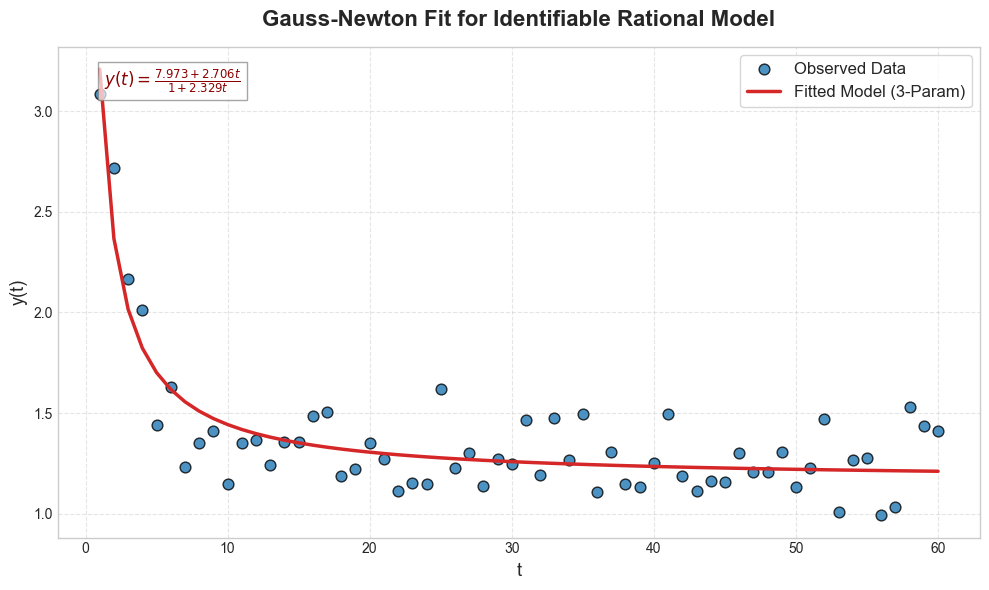

In [322]:
%reset -f
#plots Gauss-Newton fitting for identifiable rational model (3-parameter version)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

# Load data 
# try:
#     data = pd.read_csv('set-64.dat', delim_whitespace=True, header=None).to_numpy()
# except FileNotFoundError:
#     print("Error: 'set-64.dat' not found. Please place it in the same directory.")
#     exit()
data = np.load('set-64.npy')
# Extract t and y
y_data = data[:, 1]
t = np.arange(1, len(y_data) + 1)
n = len(t) # Define n

#  Model (Identifiable 3-Parameter Version)
def model(t, p):
    """
    Identifiable 3-param rational model:
    y = (a0 + a1*t) / (1 + b1*t)
    p = [a0, a1, b1]
    """
    a0, a1, b1 = p
    return (a0 + a1 * t) / (1 + b1 * t)

#  Gauss-Newton for 3-Parameter Model
def gauss_newton_3param(t, y, init_params, max_iter=1000, tol=1e-8, damping=1e-4):
    """
    Gauss-Newton for the 3-parameter identifiable model.
    """
    params = np.array(init_params, dtype=float)
    
    for iteration in range(max_iter):
        a0, a1, b1 = params
        denom = 1 + b1 * t
        
        # Check for division by zero
        if np.any(np.isclose(denom, 0)):
            denom += 1e-6

        y_pred = (a0 + a1 * t) / denom
        residuals = y - y_pred

        # Jacobian (n x 3 matrix)
        J = np.zeros((len(t), 3))
        denom2 = denom ** 2
        J[:, 0] = 1 / denom               # d/da0
        J[:, 1] = t / denom               # d/da1
        J[:, 2] = -(a0 + a1 * t) * t / denom2 # d/db1

        # Normal equation with damping
        JTJ = J.T @ J + damping * np.eye(3) # 3x3 identity
        JTr = J.T @ residuals

        # Solve for the step (using pinv for stability, though inv should work now)
        delta = np.linalg.pinv(JTJ) @ JTr
        params += delta

        if np.linalg.norm(delta) < tol:
            print(f" Converged in {iteration + 1} iterations.")
            break
    else:
        print(" Warning: Max iterations reached without convergence.")
        
    return params

# Fit model

init_guess = [2, -0.01, 0.5]


print(f"Starting 3-parameter fit with guess: {init_guess}")
estimated_params = gauss_newton_3param(t, y_data, init_guess)
y_fit = model(t, estimated_params)

print("\nEstimated parameters [α0, α1, β1]:", estimated_params)

#  Plot 
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    t, y_data,
    label='Observed Data',
    color='#1f77b4',
    edgecolor='black',
    s=60,
    alpha=0.8,
    marker='o'
)
ax.plot(
    t, y_fit,
    label='Fitted Model (3-Param)',
    color='#d62728',
    linewidth=2.5
)

# Titles and labels
ax.set_title('Gauss-Newton Fit for Identifiable Rational Model', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('t', fontsize=13)
ax.set_ylabel('y(t)', fontsize=13)

# Add annotation of fitted equation
a0, a1, b1 = estimated_params
eq_text = f"$y(t) = \\frac{{{a0:.3f} + {a1:.3f}t}}{{1 + {b1:.3f}t}}$"
ax.text(
    0.05, 0.92,
    eq_text,
    transform=ax.transAxes,
    fontsize=12,
    color='darkred',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(frameon=True, fontsize=12, loc='best')
plt.tight_layout()
plt.show()



### **Normality check -QQ plot and histogram of residuals for rational model**

Residual mean: 9.3074e-15
Residual std dev: 1.5999e-01
estimate of σ² = 0.026496297184074438

--- Normality Tests ---
Shapiro–Wilk test:       statistic = 0.9703, p-value = 0.1515
Kolmogorov–Smirnov test: statistic = 0.0985, p-value = 0.5708
Jarque–Bera test:        statistic = 1.8276, p-value = 0.4010


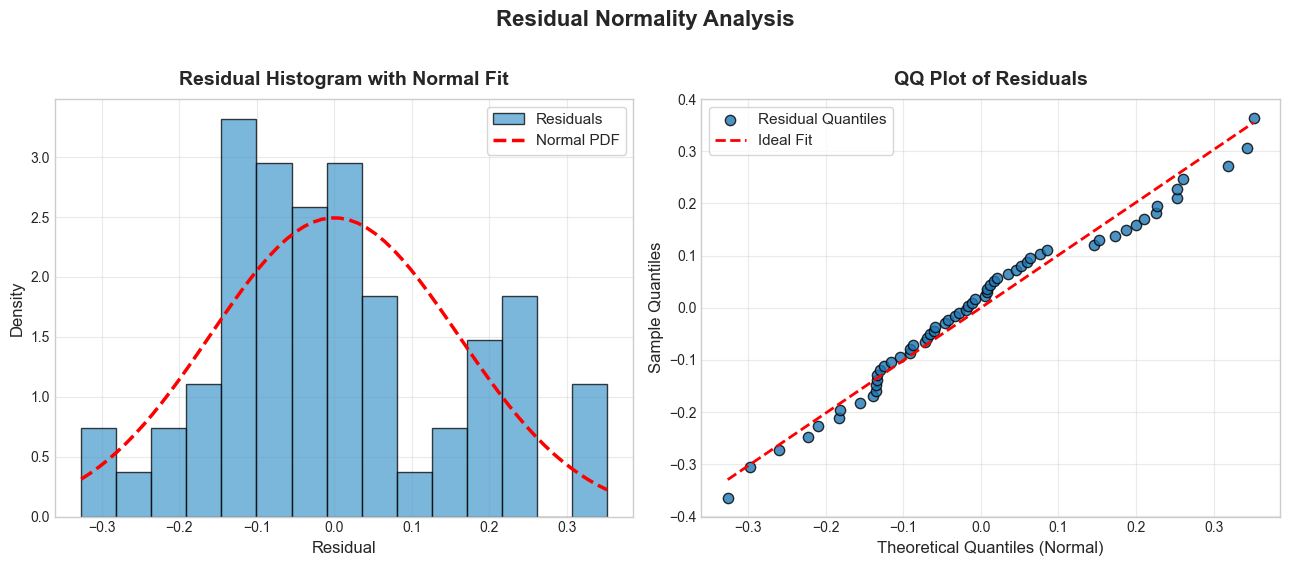

In [323]:
#plots QQ plot and histogram of residuals for rational model (3-parameter version)
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Compute residuals
residuals = y_data - y_fit

# 2. Descriptive statistics
mean_res = np.mean(residuals)
std_res = np.std(residuals, ddof=1)

print(f"Residual mean: {mean_res:.4e}")
print(f"Residual std dev: {std_res:.4e}")
print("estimate of σ² =", np.sum(residuals*residuals) / (len(residuals)-3))
# 3. Normality tests
shapiro_stat, shapiro_p = stats.shapiro(residuals)
ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(mean_res, std_res))
jb_stat, jb_p = stats.jarque_bera(residuals)

print("\n--- Normality Tests ---")
print(f"Shapiro–Wilk test:       statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
print(f"Kolmogorov–Smirnov test: statistic = {ks_stat:.4f}, p-value = {ks_p:.4f}")
print(f"Jarque–Bera test:        statistic = {jb_stat:.4f}, p-value = {jb_p:.4f}")

# 4. Aesthetic plots
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# --- (a) Histogram with normal curve ---
n, bins, patches = axes[0].hist(
    residuals,
    bins=15,
    density=True,
    color='#4f9fcf',
    edgecolor='black',
    alpha=0.75,
    label='Residuals'
)

# Normal PDF overlay
x = np.linspace(min(residuals), max(residuals), 60)
axes[0].plot(
    x,
    stats.norm.pdf(x, mean_res, std_res),
    'r--',
    lw=2.5,
    label='Normal PDF'
)

axes[0].set_title("Residual Histogram with Normal Fit", fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel("Residual", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].legend(frameon=True, fontsize=11)
axes[0].grid(alpha=0.4)

#  (b) QQ plot 
(quantiles, theoretical), (slope, intercept, r) = stats.probplot(residuals, dist="norm",sparams=(mean_res, std_res))

# custom scatter (instead of default)
axes[1].scatter(theoretical, quantiles, color="#1f77b4", edgecolor='black', s=55, alpha=0.8, label="Residual Quantiles")
# best-fit line
axes[1].plot(theoretical, slope* theoretical + intercept, 'r--', lw=2, label='Ideal Fit')

axes[1].set_title("QQ Plot of Residuals", fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel("Theoretical Quantiles (Normal)", fontsize=12)
axes[1].set_ylabel("Sample Quantiles", fontsize=12)
axes[1].legend(frameon=True, fontsize=11)
axes[1].grid(alpha=0.4)

#  Layout 
plt.suptitle("Residual Normality Analysis", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()




### **Residuals vs t for rational model**

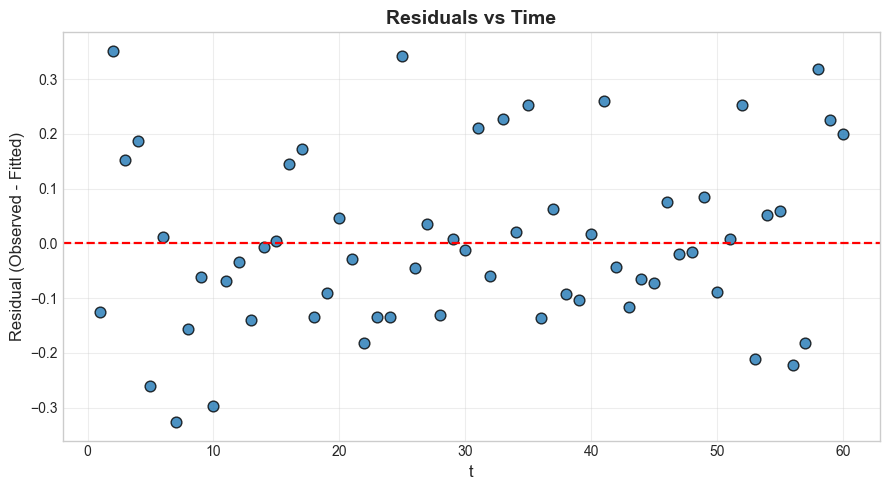

In [324]:
#plots Residuals vs t for rational model (3-parameter version)
import matplotlib.pyplot as plt
import numpy as np

# Compute residuals
y_fit = model(t, (a0, a1,b1))
residuals = y_data - y_fit

#  Residual Plot
plt.figure(figsize=(9, 5))
plt.scatter(t, residuals, color="#1f77b4", edgecolors="k", s=60, alpha=0.8)
plt.axhline(0, color='red', linestyle='--', linewidth=1.6)

plt.title("Residuals vs Time", fontsize=14, weight='bold')
plt.xlabel("t", fontsize=12)
plt.ylabel("Residual (Observed - Fitted)", fontsize=12)
plt.grid(alpha=0.35)
plt.tight_layout()
plt.show()


### **FIM and Confidence Interval Calculation for rational model**

In [325]:
#  FIM and Confidence Interval Calculation for rational model (3-parameter version)

print("\n--- 95% Confidence Interval Calculation (3-Param Model) ---")
try:
    # 1. Recalculate Final Residuals and Jacobian 
    residuals = y_data - y_fit
    rss = np.sum(residuals**2)
    
    # Recalculate the Jacobian with the final parameters
    a0, a1, b1 = estimated_params
    denom = 1 + b1 * t
    denom2 = denom ** 2
    
    J_final = np.zeros((len(t), 3))
    J_final[:, 0] = 1 / denom
    J_final[:, 1] = t / denom
    J_final[:, 2] = -(a0 + a1 * t) * t / denom2
    
    # 2. Calculate FIM and Covariance 
    m = len(estimated_params)  # Number of estimated parameters (3)

    # Use the actual number of data points (len(t)) in this scope to avoid
    # accidental overwriting of 'n' from other cells which may be an array.
    n_points = len(t)
    df = n_points - m

    # Estimate of noise variance
    # Ensure df used for division is a positive scalar
    df_safe = max(1, int(df))
    sigma2 = rss / df_safe

    # Calculate Fisher Information Matrix (FIM)
    J_T_J = J_final.T @ J_final
    fim = J_T_J / sigma2
    
    # Calculate Covariance Matrix (Inverse of FIM)
    # This should now work without error
    cov = np.linalg.inv(fim)
    
    # Standard Errors
    param_std = np.sqrt(np.diag(cov))

    # 3. Calculate Confidence Intervals 
    alpha = 0.05  # 95% confidence
    t_crit = stats.t.ppf(1 - alpha / 2, df)
    
    margin_of_error = t_crit * param_std
    ci_lower = estimated_params - margin_of_error
    ci_upper = estimated_params + margin_of_error
    
    # 4. Print the FIM 
    print("\n--- Fisher Information Matrix (FIM) [3x3] ---")
    np.set_printoptions(precision=4, suppress=True)
    print(fim)
    np.set_printoptions() # Reset to default
    
    # 5. Print the Results Table 
    print(f"\nDegrees of freedom (n-m): {df}")
    print(f"t-critical value for 95% CI: {t_crit:.4f}")
    print("-" * 65)
    print(f"{'Parameter':<10} {'Estimate':<13} {'Std. Error':<13} {'95% CI Lower':<13} {'95% CI Upper':<13}")
    print("-" * 65)

    params_names = ['a₀ (α0)', 'a₁ (α1)', 'b₁ (β1)']
    for i in range(len(estimated_params)):
        print(f"{params_names[i]:<10} {estimated_params[i]:<13.6f} {param_std[i]:<13.6f} {ci_lower[i]:<13.6f} {ci_upper[i]:<13.6f}")
    
    print("-" * 65)

except np.linalg.LinAlgError:
    print("\n--- Error ---")
    print("Error: The Fisher Information Matrix is still singular.")
    print("This is unexpected for this model, check data or initial guess.")
except RuntimeWarning as e:
    print(f"\n--- Runtime Warning Encountered ---")
    print(f"Warning: {e}")
    print("This may be due to numerical instability. Check the FIM and Cov matrices.")
except NameError as e:
    print(f"Error: A required variable was not found. ({e})")


--- 95% Confidence Interval Calculation (3-Param Model) ---

--- Fisher Information Matrix (FIM) [3x3] ---
[[   6.8254   25.8947  -45.9624]
 [  25.8947  394.1319 -527.0006]
 [ -45.9624 -527.0006  730.1159]]

Degrees of freedom (n-m): 57
t-critical value for 95% CI: 2.0025
-----------------------------------------------------------------
Parameter  Estimate      Std. Error    95% CI Lower  95% CI Upper 
-----------------------------------------------------------------
a₀ (α0)    7.973305      3.683488      0.597248      15.349362    
a₁ (α1)    2.706315      1.970409      -1.239361     6.651991     
b₁ (β1)    2.328554      1.652669      -0.980858     5.637966     
-----------------------------------------------------------------


# **MODEL-3 : Polynomial model**

### **polynomial least squares fit (degree 4)**

Estimated coefficients (β̂):
β0 = 2.682857
β1 = -0.241045
β2 = 0.013223
β3 = -0.000286
β4 = 0.000002


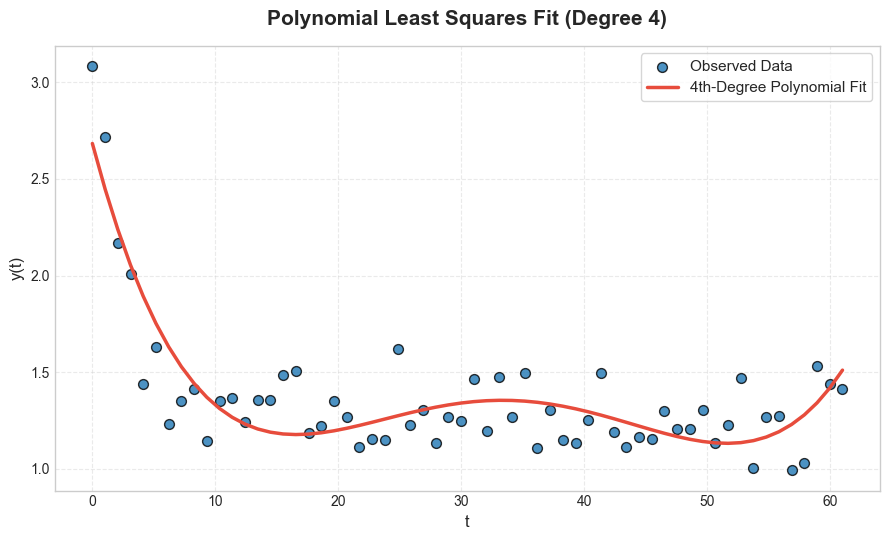

In [326]:
%reset -f
#plots polynomial least squares fit (degree 4)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load and prepare data 
# data = pd.read_csv('set-64.dat', delim_whitespace=True, header=None).to_numpy()
data = np.load('set-64.npy')
y_data = data[:, 1]
n = len(y_data)
t = np.linspace(0, len(y_data) + 1, n)

#  Design matrix for 4th-degree polynomial 
X = np.column_stack([t**i for i in range(5)])

#  Compute least squares estimator 
beta_hat = np.linalg.pinv(X) @ y_data
y_hat = X @ beta_hat

#  Print estimated coefficients 
print("Estimated coefficients (β̂):")
for i, b in enumerate(beta_hat):
    print(f"β{i} = {b:.6f}")

#  Smooth fitted curve  
t_fit = np.linspace(t.min(), t.max(), 60)
X_fit = np.column_stack([t_fit**i for i in range(5)])
y_fit = X_fit @ beta_hat

#  Plot settings 
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(9, 5.5))

# Scatter points
plt.scatter(
    t, y_data, 
    color='#1f77b4', 
    s=50, 
    edgecolor='black', 
    alpha=0.8, 
    label='Observed Data'
)

# Smooth fitted curve
plt.plot(
    t_fit, y_fit, 
    color='#e74c3c', 
    linewidth=2.5, 
    label='4th-Degree Polynomial Fit'
)

# Titles and labels
plt.title("Polynomial Least Squares Fit (Degree 4)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("t", fontsize=12)
plt.ylabel("y(t)", fontsize=12)

# Legend and grid
plt.legend(frameon=True, fontsize=11, loc='best')
plt.grid(alpha=0.4, linestyle='--')

# Extra visual touch
plt.tight_layout()
plt.show()


### **Normality check -QQ plot and histogram of residuals for polynomial fit**

Residual mean: -4.3464e-10
Residual std dev: 1.7677e-01
estimate of σ² = 0.03351874340565448

--- Normality Tests ---
Shapiro–Wilk test:       statistic = 0.9860, p-value = 0.7199
Kolmogorov–Smirnov test: statistic = 0.0674, p-value = 0.9312
Jarque–Bera test:        statistic = 0.0480, p-value = 0.9763


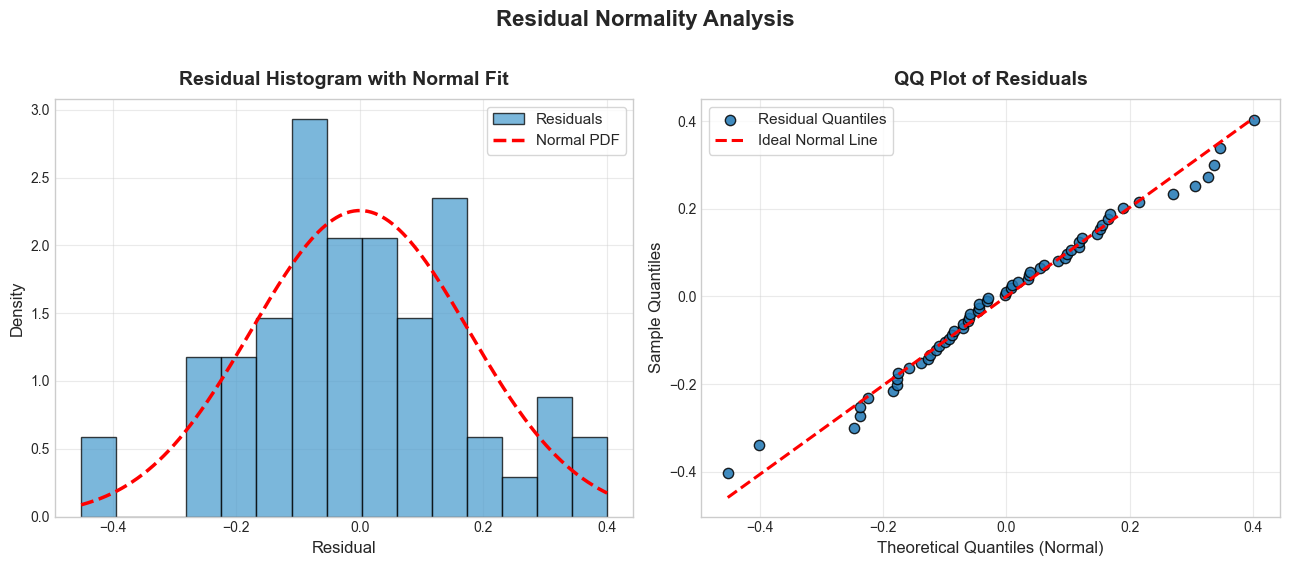

In [327]:
#plots QQ plot and histogram of residuals for polynomial fit

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


residuals = y_data - y_fit

# 2. Descriptive statistics
mean_res = np.mean(residuals)
std_res = np.std(residuals, ddof=1)

print(f"Residual mean: {mean_res:.4e}")
print(f"Residual std dev: {std_res:.4e}")
print("estimate of σ² =", np.sum(residuals*residuals) / (len(residuals)-5))
# 3. Normality tests
shapiro_stat, shapiro_p = stats.shapiro(residuals)
ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(mean_res, std_res))
jb_stat, jb_p = stats.jarque_bera(residuals)

print("\n--- Normality Tests ---")
print(f"Shapiro–Wilk test:       statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
print(f"Kolmogorov–Smirnov test: statistic = {ks_stat:.4f}, p-value = {ks_p:.4f}")
print(f"Jarque–Bera test:        statistic = {jb_stat:.4f}, p-value = {jb_p:.4f}")

# 4. Aesthetic Plots
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# (a) Histogram with normal curve
n, bins, patches = axes[0].hist(
    residuals,
    bins=15,
    density=True,
    color='#4f9fcf',
    edgecolor='black',
    alpha=0.75,
    label='Residuals'
)

# Smooth normal PDF overlay (300 points)
x = np.linspace(min(residuals), max(residuals), 300)
axes[0].plot(
    x,
    stats.norm.pdf(x, mean_res, std_res),
    'r--',
    lw=2.5,
    label='Normal PDF'
)

axes[0].set_title("Residual Histogram with Normal Fit", fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel("Residual", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].legend(frameon=True, fontsize=11)
axes[0].grid(alpha=0.4)

# --- (b) QQ Plot (customized) ---
(quantiles, theoretical), (slope, intercept, r) = stats.probplot(residuals, dist="norm",sparams=(mean_res,std_res))

# Custom scatter and ideal line
axes[1].scatter(
    theoretical,
    quantiles,
    color="#1f77b4",
    edgecolor='black',
    s=55,
    alpha=0.85,
    label="Residual Quantiles"
)
axes[1].plot(
    theoretical,
    slope * theoretical + intercept,
    'r--',
    lw=2.2,
    label="Ideal Normal Line"
)

axes[1].set_title("QQ Plot of Residuals", fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel("Theoretical Quantiles (Normal)", fontsize=12)
axes[1].set_ylabel("Sample Quantiles", fontsize=12)
axes[1].legend(frameon=True, fontsize=11)
axes[1].grid(alpha=0.4)

#  Layout 
plt.suptitle("Residual Normality Analysis", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



### **Residuals vs t for polynomial fit**

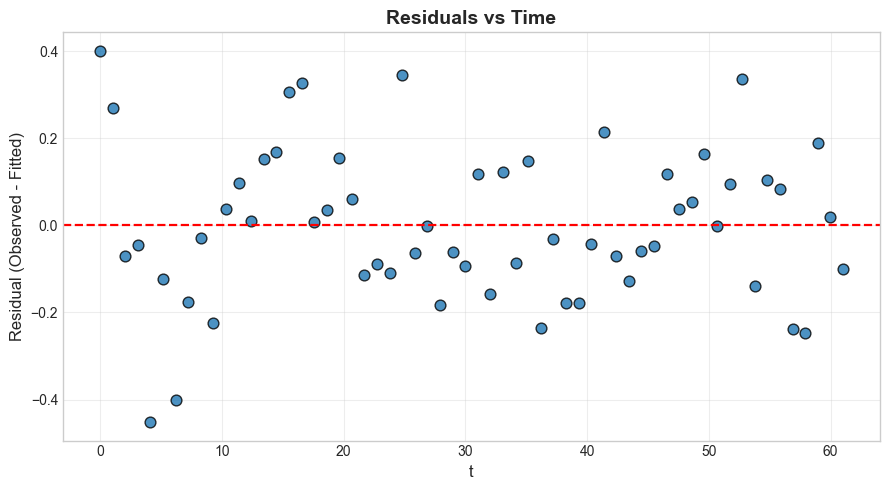

In [328]:
#plots Residuals vs t for polynomial fit
import matplotlib.pyplot as plt
import numpy as np


#  Residual Plot
plt.figure(figsize=(9, 5))
plt.scatter(t, residuals, color="#1f77b4", edgecolors="k", s=60, alpha=0.8)
plt.axhline(0, color='red', linestyle='--', linewidth=1.6)

plt.title("Residuals vs Time", fontsize=14, weight='bold')
plt.xlabel("t", fontsize=12)
plt.ylabel("Residual (Observed - Fitted)", fontsize=12)
plt.grid(alpha=0.35)
plt.tight_layout()
plt.show()


### **Fisher Information Matrix & Confidence Intervals for Polynomial Fit**

In [329]:

# Fisher Information Matrix & Confidence Intervals for Polynomial Fit

import scipy.stats as stats

print("\n--- 95% Confidence Interval Calculation ---")

#  Compute residuals
residuals = y_data - y_hat
rss = np.sum(residuals**2)
n, p = X.shape
df = n - p

#  Estimate noise variance 
sigma2 = rss / df

#  Fisher Information Matrix 
FIM = (1 / sigma2) * (X.T @ X)

#  Covariance Matrix of Parameters 
cov_beta = sigma2 * np.linalg.inv(X.T @ X)

#  Standard Errors 
param_std = np.sqrt(np.diag(cov_beta))

#  t-critical value for 95% CI 
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df)

#  Confidence Intervals 
ci_lower = beta_hat - t_crit * param_std
ci_upper = beta_hat + t_crit * param_std

#  Display Fisher Information Matrix 
print("\n--- Fisher Information Matrix (FIM) ---")
np.set_printoptions(precision=4, suppress=True)
print(FIM)
np.set_printoptions()

#  Print Summary Table 
print(f"\nDegrees of freedom (n - p): {df}")
print(f"t-critical value for 95% CI: {t_crit:.4f}")
print("-" * 70)
print(f"{'Coefficient':<12} {'Estimate':<12} {'Std. Error':<12} {'95% CI Lower':<12} {'95% CI Upper':<12}")
print("-" * 70)

for i in range(p):
    print(f"β{i:<10} {beta_hat[i]:<12.6f} {param_std[i]:<12.6f} {ci_lower[i]:<12.6f} {ci_upper[i]:<12.6f}")

print("-" * 70)



--- 95% Confidence Interval Calculation ---

--- Fisher Information Matrix (FIM) ---
[[1.7900e+03 5.4596e+04 2.2391e+06 1.0330e+08 5.0832e+09]
 [5.4596e+04 2.2391e+06 1.0330e+08 5.0832e+09 2.6055e+11]
 [2.2391e+06 1.0330e+08 5.0832e+09 2.6055e+11 1.3737e+13]
 [1.0330e+08 5.0832e+09 2.6055e+11 1.3737e+13 7.3929e+14]
 [5.0832e+09 2.6055e+11 1.3737e+13 7.3929e+14 4.0418e+16]]

Degrees of freedom (n - p): 55
t-critical value for 95% CI: 2.0040
----------------------------------------------------------------------
Coefficient  Estimate     Std. Error   95% CI Lower 95% CI Upper
----------------------------------------------------------------------
β0          2.682857     0.107284     2.467856     2.897858    
β1          -0.241045    0.024805     -0.290756    -0.191334   
β2          0.013223     0.001674     0.009868     0.016577    
β3          -0.000286    0.000041     -0.000369    -0.000203   
β4          0.000002     0.000000     0.000001     0.000003    
----------------------------